In [1]:
import sys,os
sys.path.append('../../')
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from utils import makefolder,get_acronym,depths,reduce_list_half_preserve_extremes

from geometry import * 

eps = 1E-7
rcpsize = 12
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0

In [2]:
# modelA = 'deepseek'
modelA = 'llama'
modelB = modelA
language_pairs = [('english','spanish'),
                  ]
aux_A = 'source'
aux_B = 'target'

batch_shuffle = 0
min_token_length = 7
n_files = 20
batch_size = 100
Ns = batch_size*n_files
n_tokens_list = [7]
avg = 0
Nbits_list = [0]

idx = None
match_vars = ['matching']
random_centers_list = [-1,0,1]

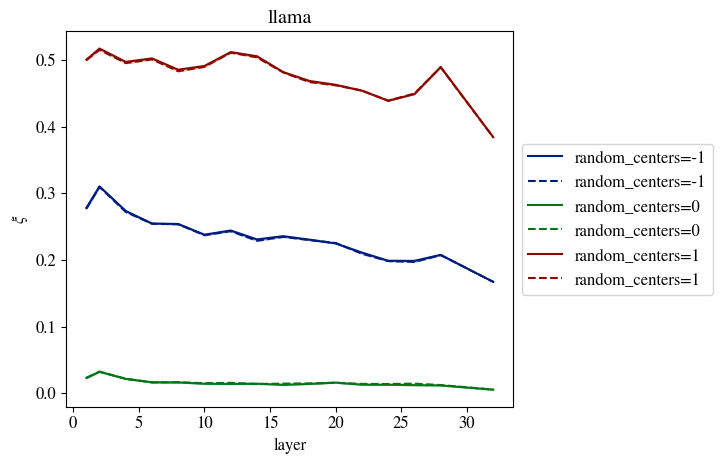

In [6]:
fig,ax = plt.subplots(1)

for random_centers_id,random_centers in enumerate(random_centers_list):

  for match_id,match_var in enumerate(match_vars):
    for Nbits_id,Nbits in enumerate(Nbits_list):
      for language_pair_id, language_pair in enumerate(language_pairs):
        for n_tokens in n_tokens_list:
          (languageA,languageB) = language_pair
          output_folder0 = makefolder(base=f'./results/',
                                        create_folder=False,
                                        modelA=modelA,
                                        modelB=modelB,
                                        match_var=match_var,
                                        n_files=n_files,
                                        min_token_length=min_token_length,
                                        )
          corr_folder = makefolder(base=output_folder0,
                                            create_folder=False,
                                            random_centers=random_centers,
                                            Nbits=Nbits,
                                            n_tokens=n_tokens,
                                            avg_tokens=avg,
                                            batch_shuffle=batch_shuffle,
                                            )
          corr_coeff = np.load(corr_folder + "corr_coeff.npy")
          std = np.load(corr_folder + "corr_coeff_jack_std.npy")

          layers_A = list(range(1,depths[modelA] + 1))
          layers_B = list(range(1,depths[modelB] + 1))
          layers = reduce_list_half_preserve_extremes(layers_A)
              
          for corr_index in range(2):
            plt.plot(layers,
                    corr_coeff[corr_index].diagonal(),
                    label=f'{random_centers=}',
                    linestyle=_linestyles[corr_index],
                    color=colors[random_centers_id],
                    )#+f' | {Nbits=}',
            plt.fill_between(layers,
                            corr_coeff[corr_index].diagonal() - std[corr_index].diagonal(),
                            corr_coeff[corr_index].diagonal() + std[corr_index].diagonal(),
                            alpha=0.2,
                            color=colors[random_centers_id],
                            )

ax.legend()
ax.set_xlabel('layer')
ax.set_ylabel(r'$\xi$')
ax.set_title(f'{modelA}')


box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

### ranks

In [ ]:
layer_A = 1
layer_B = layer_A
method = 'max'
ranks_folder = makefolder(base=output_folder0+f'ranks/{method}/',
                        create_folder=False,
                        Nbits=Nbits,
                        n_tokens=n_tokens,
                        avg_tokens=avg,
                        batch_shuffle=batch_shuffle,
                        layer_A=layer_A,
                        layer_B=layer_B,
                        )
corr_coeff = build_corr_coeff(average=False)

In [ ]:
x_ranks = jnp.array(np.load(os.path.join(ranks_folder, "x_ranks.npy")))
y_ranks = jnp.array(np.load(os.path.join(ranks_folder, "y_ranks.npy"))  )
x_l = jnp.array(np.load(os.path.join(ranks_folder, "x_l.npy")))
y_l = jnp.array(np.load(os.path.join(ranks_folder, "y_l.npy"))                        )

jack_seed = 0
ratio_jackknife = .8 
jack_key = jax.random.PRNGKey(jack_seed)
jack_indices = jax.random.choice(key=jack_key,
                                  a=x_ranks.shape[0],
                                  shape=(int(ratio_jackknife*x_ranks.shape[0]),),
                                  replace=False)

x_ranks_jack = jnp.take(x_ranks, jack_indices, axis=0)
print(f'{x_ranks_jack.shape=}')
y_ranks_jack = jnp.take(y_ranks, jack_indices, axis=0)
x_l_jack = jnp.take(x_l, jack_indices, axis=0)
y_l_jack = jnp.take(y_l, jack_indices, axis=0)

xi_AB,xi_BA = corr_coeff((x_ranks_jack,y_ranks_jack))#,(x_l,y_l))
print(xi_AB.mean(),xi_BA.mean())

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(np.asarray(xi_BA), bins=30, alpha=0.5, color='C0',label='AB')
plt.hist(np.asarray(xi_AB), bins=30, alpha=0.5, color='C0',label='BA')
plt.ylabel('Frequency')
plt.title('Distribution of xis')
plt.show()

In [ ]:
ranks_folder = makefolder(base=output_folder0+f'ranks/{method}/',
                      create_folder=False,
                      Nbits=Nbits,
                      n_tokens=n_tokens,
                      avg_tokens=avg,
                      batch_shuffle=batch_shuffle,
                      layer_A=layer_A,
                      layer_B=layer_B,
                      )
output_folder = makefolder(base=output_folder0,
                      create_folder=True,
                      Nbits=Nbits,
                      n_tokens=n_tokens,
                      avg_tokens=avg,
                      batch_shuffle=batch_shuffle,
                      )                            
x_ranks = jnp.array(np.load(os.path.join(ranks_folder, "x_ranks.npy")))
print(f'{x_ranks=}')